In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [18]:
df = pd.read_csv('../../data/01_raw/raw_emails.csv', low_memory=False)
df.columns = df.columns.str.lower().str.strip()

df.head()

,co_ref,time_to_renewal,crm_accreditation_completed,crm_timely_completion,crm_progress_towards_accreditation,crm_delays_in_accreditation,crm_contractor_suggested_leave,crm_contractor_engagement,crm_contractor_sentiment,crm_contractor_sentiment_score,...,crm_accreditation_issues,crm_membership_overdue,crm_auto_renewal_status,crm_dissatisified_with_renewal_price,crm_customer_complained,crm_refund_mentioned,crm_negative_customer_experience,crm_dissatisfaction_with_support,crm_financial_hardship_mentioned,year
0,KG5766,pre_renewal,Not Discussed,Not Discussed,Not Discussed,Yes,No,Yes,Neutral,50,...,Not Discussed,Yes,0,No,No,Yes,Yes,No,Yes,2025
1,EJ1532,14_out,Not Discussed,Not Discussed,Not Discussed,No,Not Discussed,No,Not Discussed,Not Discussed,...,Not Discussed,Not Discussed,0,Not Discussed,No,Yes,Yes,No,Not Discussed,2025
2,AA4063,prior_year,Not Discussed,Not Discussed,Not Discussed,No,No,Yes,Neutral,50,...,Not Discussed,No,0,No,No,Yes,Yes,Yes,Not Discussed,2025
3,JY9888,prior_year,No,No,Not Discussed,Yes,No,Yes,Satisfied,80,...,Not Discussed,Yes,0,Not Discussed,No,Yes,Yes,No,Not Discussed,2025
4,WO6689,pre_renewal,Not Discussed,Not Discussed,Not Discussed,No,No,Yes,Satisfied,80,...,No,No,0,No,No,Yes,Yes,No,Not Discussed,2026


In [19]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123389 entries, 0 to 123388
Data columns (total 27 columns):
 #   Column                                Non-Null Count   Dtype 
---  ------                                --------------   ----- 
 0   co_ref                                123389 non-null  object
 1   time_to_renewal                       123389 non-null  object
 2   crm_accreditation_completed           102354 non-null  object
 3   crm_timely_completion                 102354 non-null  object
 4   crm_progress_towards_accreditation    102354 non-null  object
 5   crm_delays_in_accreditation           102354 non-null  object
 6   crm_contractor_suggested_leave        102354 non-null  object
 7   crm_contractor_engagement             102354 non-null  object
 8   crm_contractor_sentiment              102354 non-null  object
 9   crm_contractor_sentiment_score        102354 non-null  object
 10  crm_dts_or_ssip_mentioned             102354 non-null  object
 11  crm_customer_

,co_ref,time_to_renewal,crm_accreditation_completed,crm_timely_completion,crm_progress_towards_accreditation,crm_delays_in_accreditation,crm_contractor_suggested_leave,crm_contractor_engagement,crm_contractor_sentiment,crm_contractor_sentiment_score,...,crm_accreditation_issues,crm_membership_overdue,crm_auto_renewal_status,crm_dissatisified_with_renewal_price,crm_customer_complained,crm_refund_mentioned,crm_negative_customer_experience,crm_dissatisfaction_with_support,crm_financial_hardship_mentioned,year
count,123389,123389,102354,102354,102354,102354,102354,102354,102354,102354,...,112234,112234,112234,112234,111914,111914,111914,111914,111914,123389.000000
unique,37964,4,3,3,3,18,3,28,12,52,...,3,53,14,6,14,27,8,57,11,NaN
top,AV6630,prior_year,No,Not Discussed,Yes,No,No,Yes,Neutral,50,...,Not Discussed,Not Discussed,0,Not Discussed,No,No,No,No,Not Discussed,NaN
freq,8,40022,46193,62517,53395,60816,79371,71129,53576,53554,...,54235,54110,105135,70611,104315,110163,66587,66336,72242,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.338442
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.473216
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026.000000


In [20]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

crm_contractor_sentiment_score          21035
crm_accreditation_completed             21035
crm_timely_completion                   21035
crm_progress_towards_accreditation      21035
crm_delays_in_accreditation             21035
crm_contractor_suggested_leave          21035
crm_contractor_engagement               21035
crm_contractor_sentiment                21035
crm_dts_or_ssip_mentioned               21035
crm_customer_payment_intention          21035
crm_financial_hardship_mentioned        11475
crm_customer_complained                 11475
crm_refund_mentioned                    11475
crm_negative_customer_experience        11475
crm_dissatisfaction_with_support        11475
crm_membership_overdue                  11155
crm_dissatisified_with_renewal_price    11155
crm_auto_renewal_status                 11155
crm_membership_level                    11155
crm_accreditation_issues                11155
crm_agent_chase_count                   11155
crm_agent_chased_contractor       

In [21]:
num_cols = [
    'crm_customer_complained',
    'crm_negative_customer_experience',
    'crm_dissatisfaction_with_support',
    'crm_financial_hardship_mentioned',
    'crm_dissatisified_with_renewal_price',
    'crm_agent_chase_count',
    'crm_contractor_sentiment_score'
]

df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

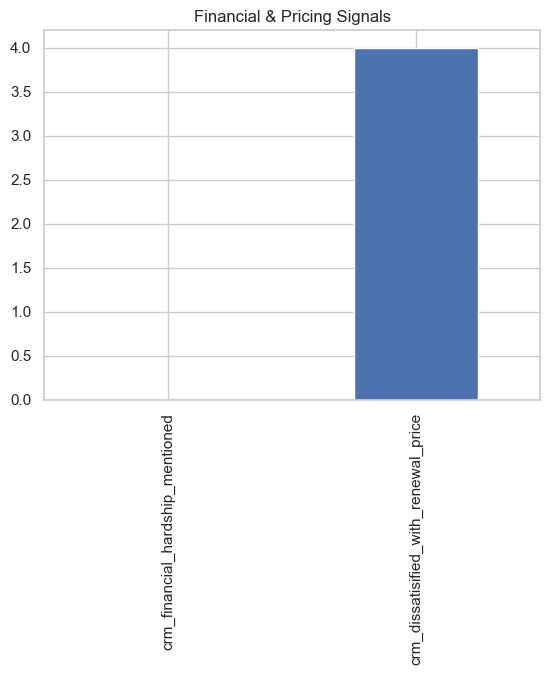

In [22]:
df[['crm_financial_hardship_mentioned',
    'crm_dissatisified_with_renewal_price']].sum().plot(kind='bar')

plt.title("Financial & Pricing Signals")
plt.show()

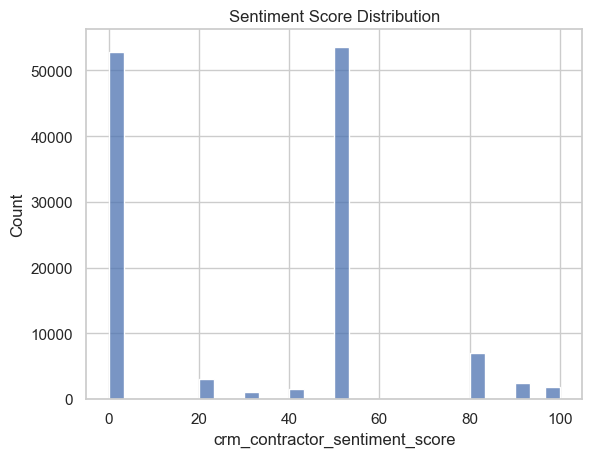

In [23]:
df['crm_contractor_sentiment_score'] = pd.to_numeric(
    df['crm_contractor_sentiment_score'], errors='coerce'
)

sns.histplot(df['crm_contractor_sentiment_score'].dropna(), bins=30)
plt.title("Sentiment Score Distribution")
plt.show()

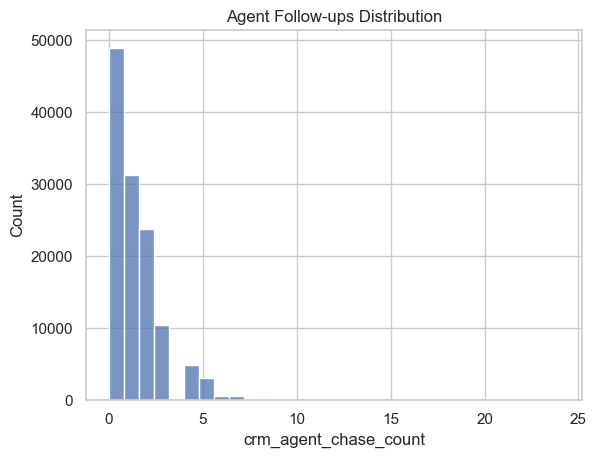

In [24]:
df['crm_agent_chase_count'] = pd.to_numeric(
    df['crm_agent_chase_count'], errors='coerce'
)

sns.histplot(df['crm_agent_chase_count'].fillna(0), bins=30)
plt.title("Agent Follow-ups Distribution")
plt.show()


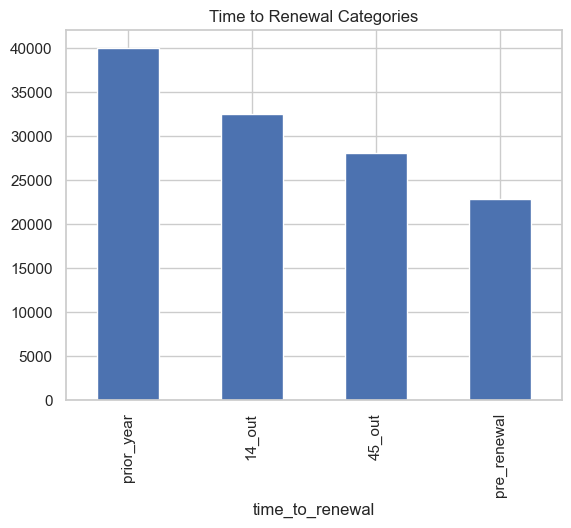

In [25]:
df['time_to_renewal'].value_counts().plot(kind='bar')

plt.title("Time to Renewal Categories")
plt.show()

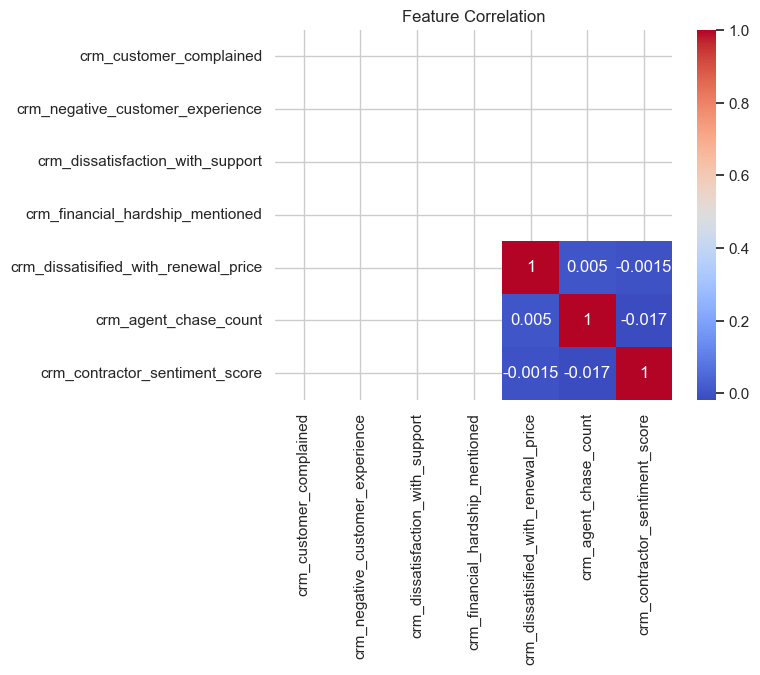

In [26]:
num_cols = [
    'crm_customer_complained',
    'crm_negative_customer_experience',
    'crm_dissatisfaction_with_support',
    'crm_financial_hardship_mentioned',
    'crm_dissatisified_with_renewal_price',
    'crm_agent_chase_count',
    'crm_contractor_sentiment_score'
]

df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()